# Stock Turnover Validation

This notebook documents the **stock turnover** mechanism in GHIM's energy module — the system that prevents instantaneous technology switching by modelling gradual capital fleet replacement.

**Structure:**
1. Part 1: Mathematical framework — equations, parameters, design choices
2. Part 2: Numerical results — sector-by-sector behavior under SSP2 baseline

---
# Part 1: Mathematical Framework

## 1.1 Core Turnover Equation

Source: `ghim/energy/stock.py`

At each period, existing technology shares blend toward logit-determined target shares:

$$
s_i^{\text{eff}}(t) = s_i^{\text{current}}(t-\Delta t) + \underbrace{\min\!\left(\frac{\Delta t}{\tau}, 1\right)}_{\text{blend rate}} \cdot \left[s_i^{\text{target}}(t) - s_i^{\text{current}}(t-\Delta t)\right]
$$

where:
- $s_i^{\text{current}}$ = fleet/stock share from previous period
- $s_i^{\text{target}}$ = ideal share from logit competition (new investment allocation)
- $\Delta t = 5$ years (model timestep)
- $\tau$ = sector-specific turnover time (years)
- After blending, shares are clipped to $\geq 0$ and renormalized to sum to 1

**Physical interpretation:** Each period, a fraction $\Delta t / \tau$ of the fleet is replaced. New capacity follows the logit target, while $(1 - \Delta t/\tau)$ of the old fleet persists.

This is a **first-order exponential decay** toward the target. The fraction of gap closed after $n$ periods:

$$
\text{gap\_closed}(n) = 1 - \left(1 - \frac{\Delta t}{\tau}\right)^n
$$

Time to close 90% of the gap: $n_{90} = \frac{\ln(0.1)}{\ln(1 - \Delta t/\tau)}$ periods.

## 1.2 Logit Target Shares (Relative-Preference Logit)

Source: `ghim/energy/logit.py:relative_pref_logit()`

The target shares that stock turnover blends toward are computed via:

$$
s_i^{\text{target}} = \frac{\alpha_i \cdot e^{-k P_i} \cdot C_i^{\beta}}{\sum_j \alpha_j \cdot e^{-k P_j} \cdot C_j^{\beta}}
$$

where:
- $\alpha_i \in \{0, 1\}$ = binary technology availability (policy switch)
- $k = 0.3$ (`PREF_LOGIT_SCALE`) = preference sensitivity ($/GJ)$^{-1}$
- $P_i$ = preference factor ($/GJ equivalent), calibrated at base year, decays over time
- $C_i$ = levelized cost of energy ($/GJ)
- $\beta = -4.0$ (`LOGIT_EXP_PREF`) = cost elasticity exponent

### Preference factor calibration

Source: `ghim/energy/logit.py:preference_calibrate()`

At the base year, $P_i$ is calibrated to reproduce observed shares given observed costs. Let $r$ be the reference technology (highest share):

$$
P_i = \frac{\beta}{k}\left(\ln C_i - \ln C_r\right) - \frac{1}{k}\ln\frac{S_i}{S_r}, \quad P_r = 0
$$

### Preference factor decay

$$
P_i(t) = P_i^{\text{base}} \cdot (1 - \delta_i)^{t - t_0}
$$

| Technology | $\delta_i$ (annual decay) | 50-yr retention |
|------------|---------------------------|------------------|
| solar, wind, electrolysis | 0.03 | 22% |
| electricity, biomass | 0.02 | 36% |
| nuclear | 0.01 | 61% |
| coal, gas, oil, hydro | 0.00 | 100% |

## 1.3 Learning-by-Doing (Cost Feedback)

Source: `ghim/energy/technology.py:Technology.update_learning()`

After stock turnover allocates generation, cumulative capacity updates and capital costs decline:

$$
C_{\text{cap},i}(t) = C_{\text{cap},i}^{0} \cdot \left(\frac{Q_{\text{cum},i}(t)}{Q_{\text{cum},i}^{0}}\right)^{\eta_i}, \quad \eta_i = \frac{\ln(1 - LR_i)}{\ln 2}
$$

with a cost floor at $C_{\text{cap},i}^{\min} = 0.2 \cdot C_{\text{cap},i}^{0}$.

| Technology | $LR_i$ | Doublings to halve cost |
|------------|---------|-------------------------|
| solar | 0.20 | 3.1 |
| wind | 0.12 | 5.4 |
| electrolysis | 0.15 | 4.3 |
| biomass | 0.05 | 13.5 |

## 1.4 Turnover Time Parameters

Source: `ghim/config.py:TURNOVER_TIMES`

| Sector | $\tau$ (years) | Blend rate $\Delta t/\tau$ | Periods to 90% | Physical basis |
|--------|----------------|---------------------------|-----------------|----------------|
| Data centers | 7 | 0.714 | 3 (15 yr) | Server refresh |
| Transport (fleet) | 15 | 0.333 | 6 (30 yr) | Vehicle lifetime |
| Hydrogen | 25 | 0.200 | 11 (55 yr) | H2 plant lifetime |
| Industry | 30 | 0.167 | 13 (65 yr) | Boiler/furnace lifetime |
| Electricity | 40 | 0.125 | 17 (85 yr) | Power plant lifetime |
| Refining | 40 | 0.125 | 17 (85 yr) | Refinery lifetime |
| Buildings | 50 | 0.100 | 22 (110 yr) | Building shell lifetime |
| Structural (top) | 50–60 | 0.083–0.100 | 22–27 | Sector composition inertia |

## 1.5 Nested Demand Tree with Multi-Level Turnover

Source: `ghim/energy/demand.py`

Demand sectors use a **hierarchical tree** where stock turnover is applied at every nesting level:

```
transport (τ=50y, k=0.05)          ← structural split, very slow
├── passenger (τ=15y, k=0.30)      ← fleet turnover
│   ├── refined_liquids: 0.87
│   ├── electricity: 0.05
│   ├── gas: 0.04
│   ├── hydrogen: 0.02
│   └── biomass: 0.02
└── freight (τ=15y, k=0.30)
    ├── refined_liquids: 0.95
    ├── gas: 0.02
    ├── electricity: 0.01
    ├── hydrogen: 0.01
    └── biomass: 0.01

industry (τ=50y, k=0.05)
├── heavy (τ=30y)
│   └── [coal 0.35, gas 0.25, elec 0.15, ...]
├── light (τ=30y)
│   └── [elec 0.40, gas 0.25, ...]
└── data_centers (τ=7y)
    └── electricity: 1.0

buildings (τ=60y, k=0.05)
├── residential (τ=50y)
│   └── [elec 0.35, gas 0.30, biomass 0.18, ...]
└── commercial (τ=50y)
    └── [elec 0.50, gas 0.30, ...]
```

**Key design:** Top-level nodes (sector→subsector split) use very low `scale_k=0.05` and high $\tau=50$–60y. This means the structural composition (e.g. passenger vs freight share) is almost price-insensitive and changes extremely slowly — driven more by income/demographic shifts than fuel prices.

## 1.6 Full Pipeline per Period

For each region at each 5-year step:

1. **Logit target shares** — compute $s_i^{\text{target}}$ from current costs, decayed preferences, and policy constraints ($\alpha$)
2. **Stock turnover blend** — $s_i^{\text{eff}} = s_i^{\text{current}} + (\Delta t/\tau)(s_i^{\text{target}} - s_i^{\text{current}})$
3. **Policy share constraints** — clamp shares to min/max bounds, renormalize
4. **Demand allocation** — $\text{gen}_i = s_i^{\text{final}} \times \text{total\_demand}$
5. **Learning update** — cumulative capacity grows → capital cost declines
6. **State persistence** — $s_i^{\text{current}}$ carried to next period

### Design choice: No explicit vintage tracking

Unlike GCAM (which tracks multi-period technology vintages with explicit decommissioning), GHIM uses **continuous share blending**. This is a deliberate simplification:

- Pros: Simpler, faster, fewer state variables
- Cons: Cannot distinguish 2000-vintage vs 2010-vintage coal plants
- Appropriate for: 5-year resolution IAM, policy scenario analysis (not dispatch modeling)

---
# Part 2: Numerical Results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import copy
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from ghim.config import (
    TURNOVER_TIMES, TIMESTEP, BASE_YEAR,
    PREF_LOGIT_SCALE, LOGIT_EXP_PREF, PREF_DECAY_RATES,
)
from ghim.energy.stock import apply_stock_turnover
from ghim.energy.logit import relative_pref_logit, preference_calibrate
from ghim.energy.electricity import ElectricitySector
from ghim.energy.hydrogen import HydrogenSector
from ghim.energy.demand import (
    _default_transport_tree, _default_industry_tree, _default_buildings_tree,
)
from ghim.energy.technology import default_electricity_techs

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Imports OK')

Imports OK


## 2.1 Blend Rate Mechanics — Exponential Convergence

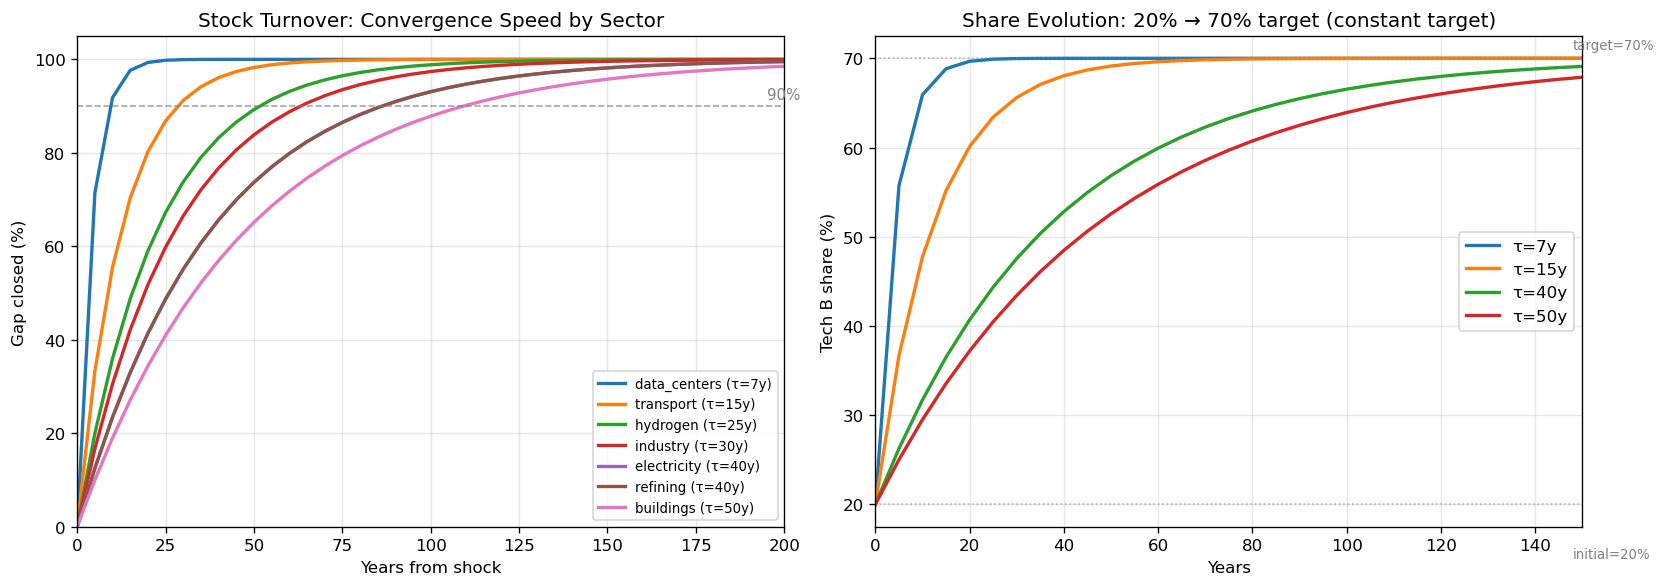

In [2]:
# Demonstrate convergence for different turnover times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: gap closure over time for each sector
ax = axes[0]
periods = np.arange(0, 41)  # 0 to 200 years
for sector, tau in sorted(TURNOVER_TIMES.items(), key=lambda x: x[1]):
    blend = min(TIMESTEP / tau, 1.0)
    gap_closed = 1 - (1 - blend) ** periods
    ax.plot(periods * TIMESTEP, gap_closed * 100, label=f'{sector} (τ={tau:.0f}y)', lw=2)

ax.axhline(90, color='gray', ls='--', lw=1, alpha=0.7)
ax.text(195, 91.5, '90%', fontsize=9, color='gray')
ax.set_xlabel('Years from shock')
ax.set_ylabel('Gap closed (%)')
ax.set_title('Stock Turnover: Convergence Speed by Sector')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 200)
ax.set_ylim(0, 105)

# Right: share evolution for a 2-tech example
ax = axes[1]
for tau, color in [(7, 'C0'), (15, 'C1'), (40, 'C2'), (50, 'C3')]:
    current = np.array([0.8, 0.2])
    target = np.array([0.3, 0.7])
    shares_history = [current.copy()]
    for _ in range(30):
        current = apply_stock_turnover(current, target, TIMESTEP, tau)
        shares_history.append(current.copy())
    shares_arr = np.array(shares_history)
    years = np.arange(len(shares_history)) * TIMESTEP
    ax.plot(years, shares_arr[:, 1] * 100, label=f'τ={tau}y', lw=2, color=color)

ax.axhline(70, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(148, 71, 'target=70%', fontsize=8, color='gray')
ax.axhline(20, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(148, 14, 'initial=20%', fontsize=8, color='gray')
ax.set_xlabel('Years')
ax.set_ylabel('Tech B share (%)')
ax.set_title('Share Evolution: 20% → 70% target (constant target)')
ax.legend()
ax.set_xlim(0, 150)

plt.tight_layout()
plt.show()

## 2.2 Electricity Sector — Share Dynamics under SSP2 Baseline

Run the electricity sector for 2020–2150 with:
- Fixed fuel prices (baseline, no trade)
- Learning-by-doing enabled
- Preference factor decay enabled
- No policy constraints

In [3]:
# Set up electricity sector
from ghim.data.energy_cal import DEFAULT_ELEC_SHARES, DEFAULT_ELEC_TOTAL_EJ

# Use a representative region
region = 'North America'
base_shares = DEFAULT_ELEC_SHARES[region]
base_total = DEFAULT_ELEC_TOTAL_EJ[region]

fuel_prices = {
    'coal': 2.0, 'gas': 5.0, 'nuclear': 1.0,
    'hydro': 0.0, 'wind': 0.0, 'solar': 0.0,
    'biomass': 3.5, 'refined liquids': 12.0,
}

# Create and calibrate
sector = ElectricitySector()
sector.calibrate(base_shares, fuel_prices)

print(f'Region: {region}')
print(f'Base shares: {base_shares}')
print(f'Base total: {base_total:.2f} EJ')
print(f'Turnover time: {sector.turnover_time} years')
print(f'\nCalibrated preference factors:')
for t, pf in zip(sector.techs, sector.pref_factors):
    print(f'  {t.name:10s}: PF={pf:+7.2f} $/GJ, LCOE={t.levelized_cost(fuel_prices.get(t.fuel_input, 3.0)):.2f} $/GJ')

Region: North America
Base shares: {'coal': 0.2, 'gas_cc': 0.4, 'nuclear': 0.2, 'hydro': 0.07, 'wind': 0.08, 'solar': 0.03, 'biomass': 0.01, 'oil': 0.01}
Base total: 18.50 EJ
Turnover time: 40.0 years

Calibrated preference factors:
  coal      : PF=  +4.64 $/GJ, LCOE=11.02 $/GJ
  gas_cc    : PF=  +0.00 $/GJ, LCOE=13.12 $/GJ
  nuclear   : PF=  -1.37 $/GJ, LCOE=17.29 $/GJ
  hydro     : PF=  +7.91 $/GJ, LCOE=11.20 $/GJ
  wind      : PF=  +9.01 $/GJ, LCOE=9.98 $/GJ
  solar     : PF= +12.03 $/GJ, LCOE=10.17 $/GJ
  biomass   : PF=  +6.59 $/GJ, LCOE=20.13 $/GJ
  oil       : PF=  -2.67 $/GJ, LCOE=40.32 $/GJ


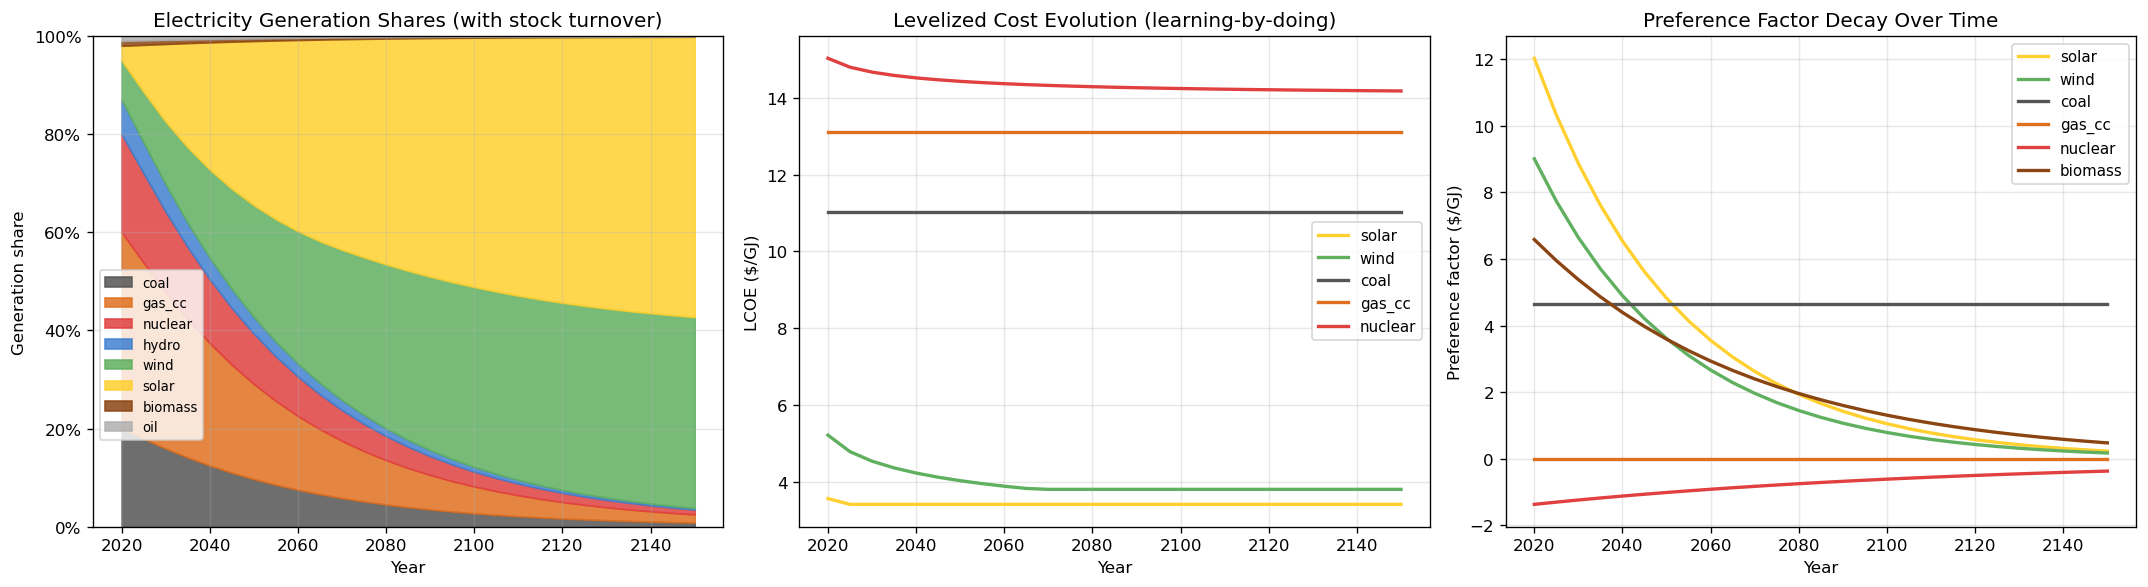

In [4]:
# Run over projection horizon
years = list(range(2020, 2155, TIMESTEP))
tech_names = sector.tech_names
share_history = {t: [] for t in tech_names}
cost_history = {t: [] for t in tech_names}
pf_history = {t: [] for t in tech_names}

# Growing demand (approx SSP2)
demand_growth = 1.01  # 1% annual growth
demand = base_total

for yr in years:
    gen = sector.compute_supply(fuel_prices, demand, year=yr)
    total_gen = sum(gen.values())
    
    for t in sector.techs:
        s = gen[t.name] / total_gen if total_gen > 0 else 0
        share_history[t.name].append(s)
        cost_history[t.name].append(t.levelized_cost(fuel_prices.get(t.fuel_input, 3.0)))
        pf_history[t.name].append(sector.pref_factors[sector.tech_names.index(t.name)])
    
    demand *= demand_growth ** TIMESTEP

# Plot shares
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stacked area chart of generation shares
ax = axes[0]
colors = {
    'coal': '#555555', 'gas_cc': '#E07020', 'nuclear': '#E04040',
    'hydro': '#4080D0', 'wind': '#60B060', 'solar': '#FFD030',
    'biomass': '#8B4513', 'oil': '#B0B0B0',
}
bottom = np.zeros(len(years))
for t_name in tech_names:
    vals = np.array(share_history[t_name])
    ax.fill_between(years, bottom, bottom + vals, label=t_name,
                    color=colors.get(t_name, '#999'), alpha=0.85)
    bottom += vals
ax.set_xlabel('Year')
ax.set_ylabel('Generation share')
ax.set_title('Electricity Generation Shares (with stock turnover)')
ax.legend(loc='center left', bbox_to_anchor=(0, 0.35), fontsize=8)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# LCOE evolution (learning effect)
ax = axes[1]
for t_name in ['solar', 'wind', 'coal', 'gas_cc', 'nuclear']:
    ax.plot(years, cost_history[t_name], label=t_name, lw=2,
            color=colors.get(t_name, '#999'))
ax.set_xlabel('Year')
ax.set_ylabel('LCOE ($/GJ)')
ax.set_title('Levelized Cost Evolution (learning-by-doing)')
ax.legend(fontsize=9)

# Preference factor decay
ax = axes[2]
for t_name in ['solar', 'wind', 'coal', 'gas_cc', 'nuclear', 'biomass']:
    ax.plot(years, pf_history[t_name], label=t_name, lw=2,
            color=colors.get(t_name, '#999'))
ax.set_xlabel('Year')
ax.set_ylabel('Preference factor ($/GJ)')
ax.set_title('Preference Factor Decay Over Time')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2.3 Turnover vs No-Turnover Comparison

Compare the same electricity sector with and without stock turnover ($\tau = 40y$ vs instant).

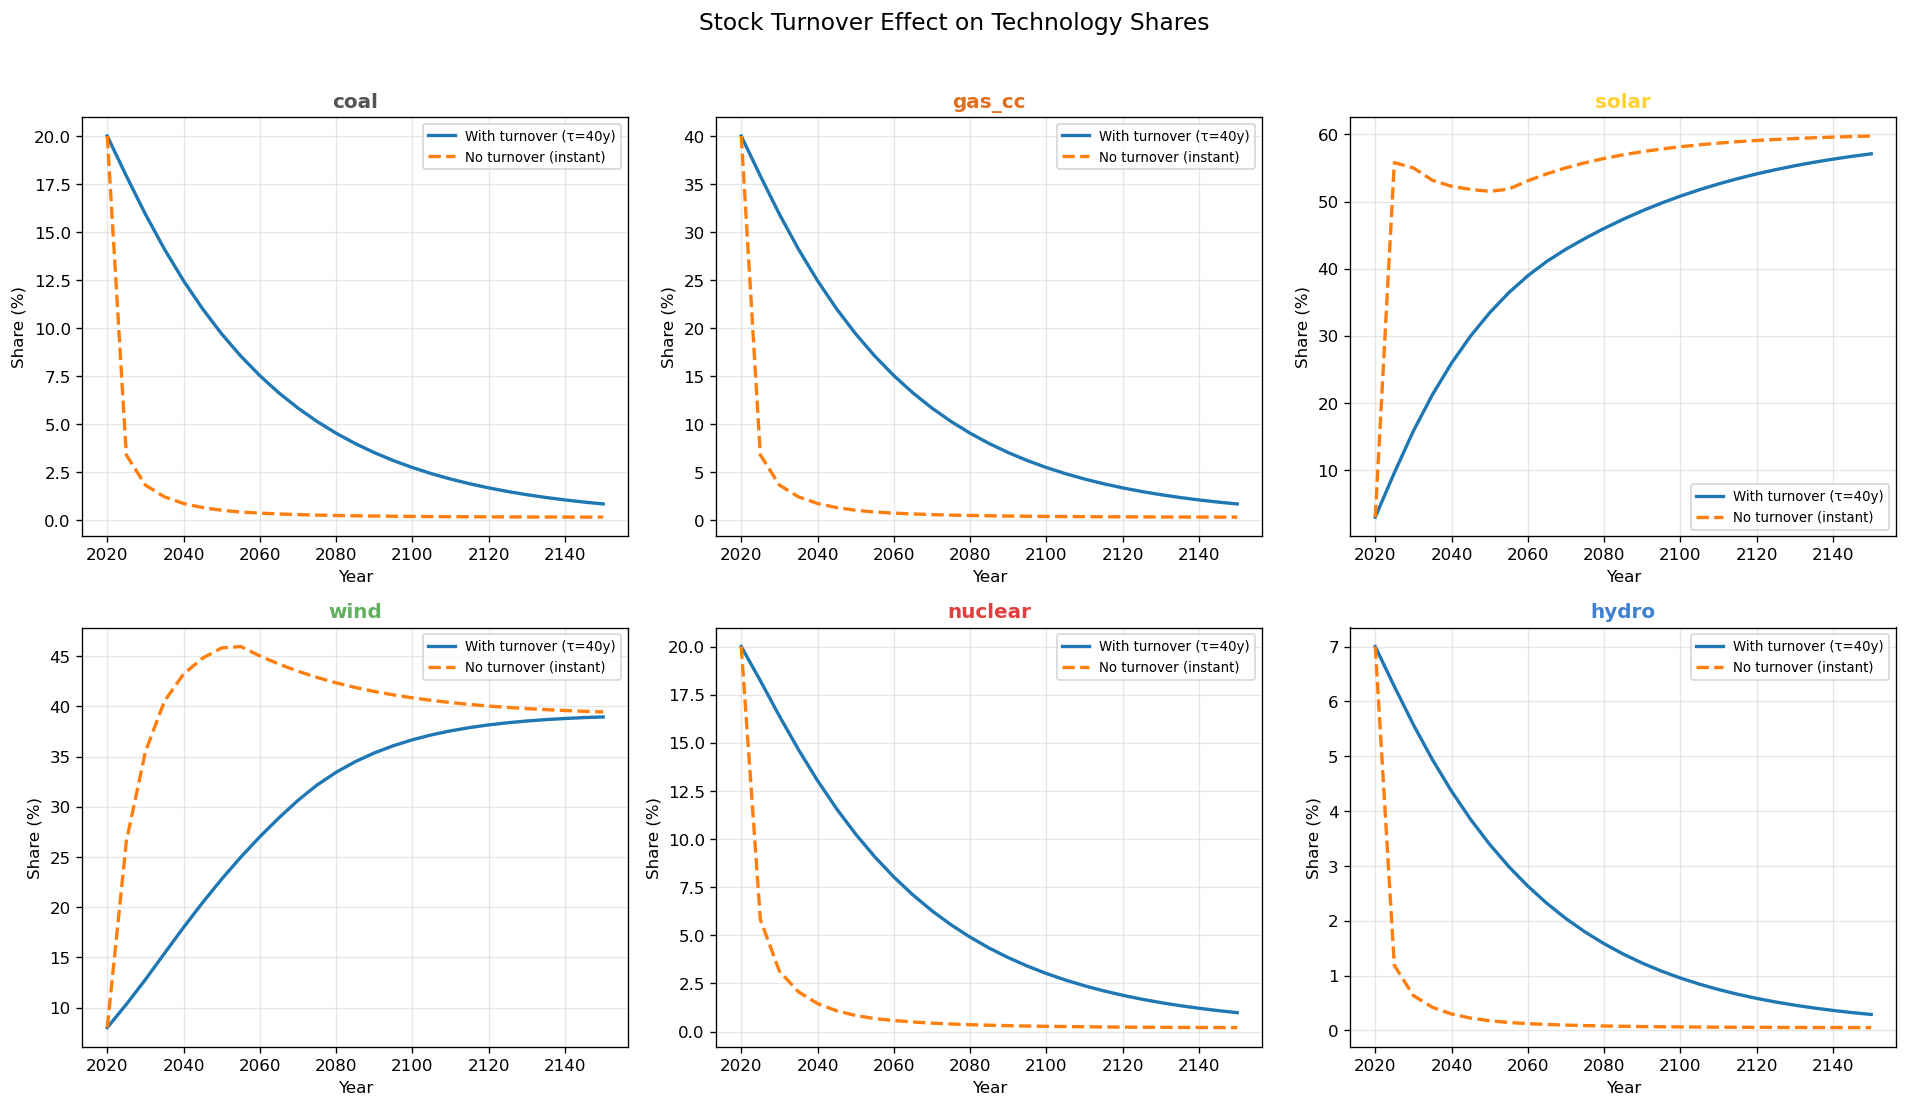

In [5]:
# Run with turnover (default τ=40) and without (τ=1, effectively instant)
results = {}
for label, tau_override in [('With turnover (τ=40y)', None), ('No turnover (instant)', 1.0)]:
    sec = ElectricitySector(
        turnover_time=tau_override if tau_override else TURNOVER_TIMES['electricity'],
    )
    sec.calibrate(base_shares, fuel_prices)
    
    history = {t: [] for t in sec.tech_names}
    demand = base_total
    for yr in years:
        gen = sec.compute_supply(fuel_prices, demand, year=yr)
        total_gen = sum(gen.values())
        for t_name in sec.tech_names:
            history[t_name].append(gen[t_name] / total_gen if total_gen > 0 else 0)
        demand *= demand_growth ** TIMESTEP
    results[label] = history

# Plot comparison for key techs
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
key_techs = ['coal', 'gas_cc', 'solar', 'wind', 'nuclear', 'hydro']

for ax, t_name in zip(axes.flat, key_techs):
    for label, history in results.items():
        ls = '-' if 'With' in label else '--'
        ax.plot(years, np.array(history[t_name]) * 100, label=label, lw=2, ls=ls)
    ax.set_title(t_name, fontsize=12, fontweight='bold',
                 color=colors.get(t_name, 'black'))
    ax.set_xlabel('Year')
    ax.set_ylabel('Share (%)')
    ax.legend(fontsize=8)

fig.suptitle('Stock Turnover Effect on Technology Shares', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.4 Hydrogen Sector — SMR vs Electrolysis Transition

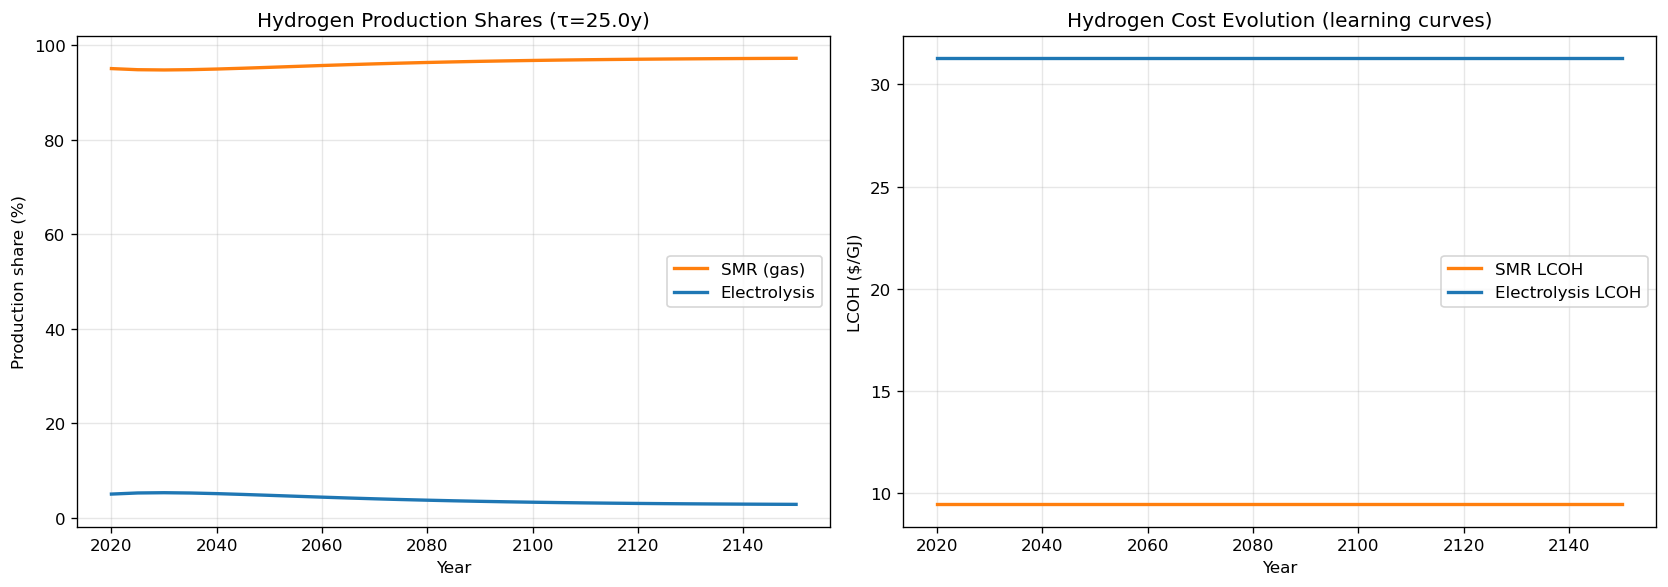

In [6]:
# Hydrogen sector: SMR (gas) vs electrolysis (electricity)
h2_base_shares = {'smr': 0.95, 'electrolysis': 0.05}
h2_fuel_prices = {'gas': 5.0, 'electricity': 20.0}

h2_sector = HydrogenSector()
h2_sector.calibrate(h2_base_shares, h2_fuel_prices)

h2_shares = {'smr': [], 'electrolysis': []}
h2_costs = {'smr': [], 'electrolysis': []}
h2_demand = 0.5  # Starting H2 demand (EJ)

for yr in years:
    prod = h2_sector.compute_supply(h2_fuel_prices, h2_demand, year=yr)
    total = sum(prod.values())
    for t_name in ['smr', 'electrolysis']:
        h2_shares[t_name].append(prod[t_name] / total if total > 0 else 0)
    for t in h2_sector.techs:
        h2_costs[t.name].append(t.levelized_cost(h2_fuel_prices.get(t.fuel_input, 3.0)))
    h2_demand *= 1.02 ** TIMESTEP  # 2% annual growth

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(years, np.array(h2_shares['smr']) * 100, label='SMR (gas)', lw=2, color='C1')
ax.plot(years, np.array(h2_shares['electrolysis']) * 100, label='Electrolysis', lw=2, color='C0')
ax.set_xlabel('Year')
ax.set_ylabel('Production share (%)')
ax.set_title(f'Hydrogen Production Shares (τ={h2_sector.turnover_time}y)')
ax.legend()

ax = axes[1]
ax.plot(years, h2_costs['smr'], label='SMR LCOH', lw=2, color='C1')
ax.plot(years, h2_costs['electrolysis'], label='Electrolysis LCOH', lw=2, color='C0')
ax.set_xlabel('Year')
ax.set_ylabel('LCOH ($/GJ)')
ax.set_title('Hydrogen Cost Evolution (learning curves)')
ax.legend()

plt.tight_layout()
plt.show()

## 2.5 Nested Demand Trees — Fuel Switching Dynamics

Run each demand sector tree over time and observe how fuel shares evolve through nested turnover.

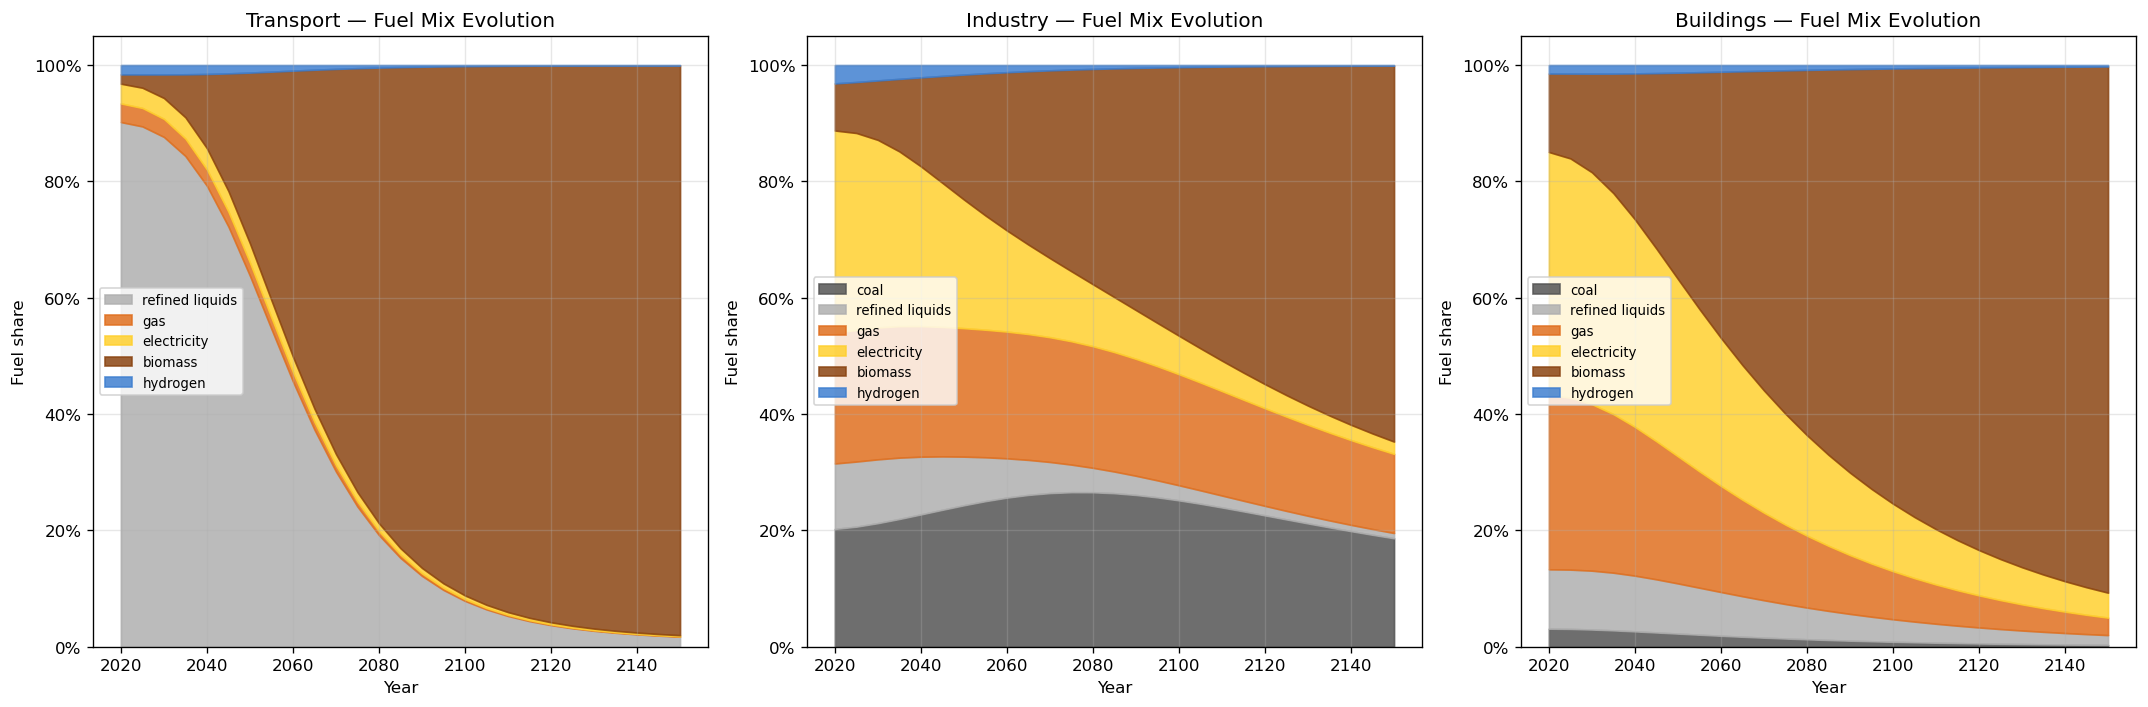

In [7]:
# Run each sector tree over time
demand_fuel_prices = {
    'coal': 2.0, 'refined liquids': 12.0, 'gas': 5.0,
    'electricity': 20.0, 'biomass': 3.5, 'hydrogen': 30.0,
}

sector_factories = {
    'Transport': _default_transport_tree,
    'Industry': _default_industry_tree,
    'Buildings': _default_buildings_tree,
}

carrier_colors = {
    'coal': '#555555', 'refined liquids': '#B0B0B0', 'gas': '#E07020',
    'electricity': '#FFD030', 'biomass': '#8B4513', 'hydrogen': '#4080D0',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (sector_name, factory) in zip(axes, sector_factories.items()):
    tree = factory()
    tree.calibrate(demand_fuel_prices)
    
    carrier_history = {}
    for yr in years:
        demands = tree.compute_carrier_demands(10.0, demand_fuel_prices, year=yr)
        total = sum(demands.values())
        for carrier, val in demands.items():
            if carrier not in carrier_history:
                carrier_history[carrier] = []
            carrier_history[carrier].append(val / total if total > 0 else 0)
    
    # Fill missing years with 0
    for carrier in carrier_history:
        while len(carrier_history[carrier]) < len(years):
            carrier_history[carrier].append(0)
    
    # Stacked area
    bottom = np.zeros(len(years))
    for carrier in ['coal', 'refined liquids', 'gas', 'electricity', 'biomass', 'hydrogen']:
        if carrier in carrier_history:
            vals = np.array(carrier_history[carrier])
            ax.fill_between(years, bottom, bottom + vals, label=carrier,
                           color=carrier_colors.get(carrier, '#999'), alpha=0.85)
            bottom += vals
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Fuel share')
    ax.set_title(f'{sector_name} — Fuel Mix Evolution')
    ax.legend(loc='center left', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## 2.6 Policy Experiment: Coal Ban with Stock Turnover

Set $\alpha_{\text{coal}} = 0$ starting in 2030 and observe how coal share declines through stock turnover.

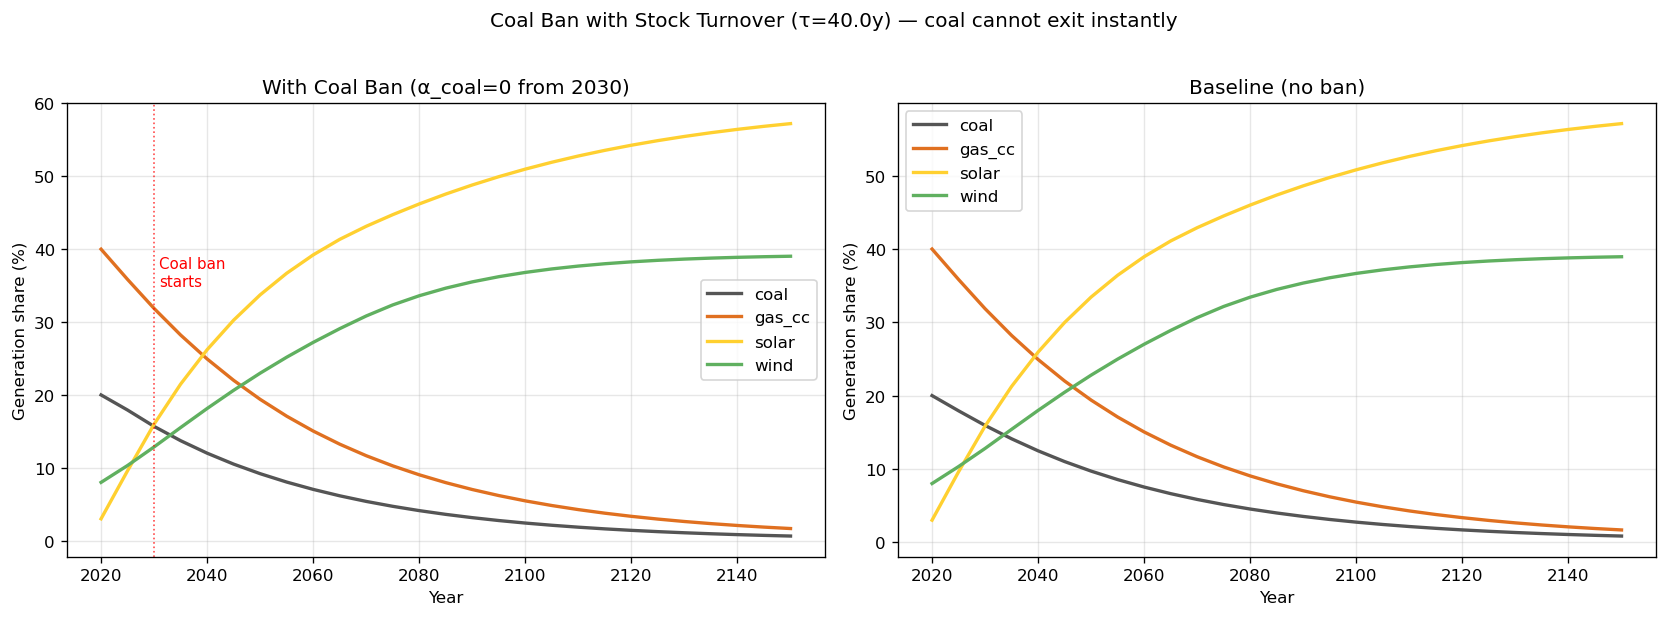

In [8]:
# Coal ban experiment
sector_ban = ElectricitySector()
sector_ban.calibrate(base_shares, fuel_prices)

sector_noban = ElectricitySector()
sector_noban.calibrate(base_shares, fuel_prices)

ban_history = {'coal': [], 'solar': [], 'wind': [], 'gas_cc': []}
noban_history = {'coal': [], 'solar': [], 'wind': [], 'gas_cc': []}

demand = base_total
for yr in years:
    # With coal ban from 2030
    alpha_ban = None
    if yr >= 2030:
        alpha_ban = np.array([
            0.0 if t.name == 'coal' else 1.0
            for t in sector_ban.techs
        ])
    gen_ban = sector_ban.compute_supply(fuel_prices, demand, year=yr, alpha=alpha_ban)
    gen_noban = sector_noban.compute_supply(fuel_prices, demand, year=yr)
    
    total_ban = sum(gen_ban.values())
    total_noban = sum(gen_noban.values())
    
    for t_name in ban_history:
        ban_history[t_name].append(gen_ban.get(t_name, 0) / total_ban * 100)
        noban_history[t_name].append(gen_noban.get(t_name, 0) / total_noban * 100)
    
    demand *= demand_growth ** TIMESTEP

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for t_name in ['coal', 'gas_cc', 'solar', 'wind']:
    ax.plot(years, ban_history[t_name], label=t_name, lw=2,
            color=colors.get(t_name, '#999'))
ax.axvline(2030, color='red', ls=':', lw=1, alpha=0.7)
ax.text(2031, 35, 'Coal ban\nstarts', fontsize=9, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Generation share (%)')
ax.set_title('With Coal Ban (α_coal=0 from 2030)')
ax.legend()

ax = axes[1]
for t_name in ['coal', 'gas_cc', 'solar', 'wind']:
    ax.plot(years, noban_history[t_name], label=t_name, lw=2,
            color=colors.get(t_name, '#999'))
ax.set_xlabel('Year')
ax.set_ylabel('Generation share (%)')
ax.set_title('Baseline (no ban)')
ax.legend()

fig.suptitle(f'Coal Ban with Stock Turnover (τ={TURNOVER_TIMES["electricity"]}y) — coal cannot exit instantly',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 2.7 Sensitivity to Turnover Time

Test the electricity sector with different $\tau$ values to see how the transition speed varies.

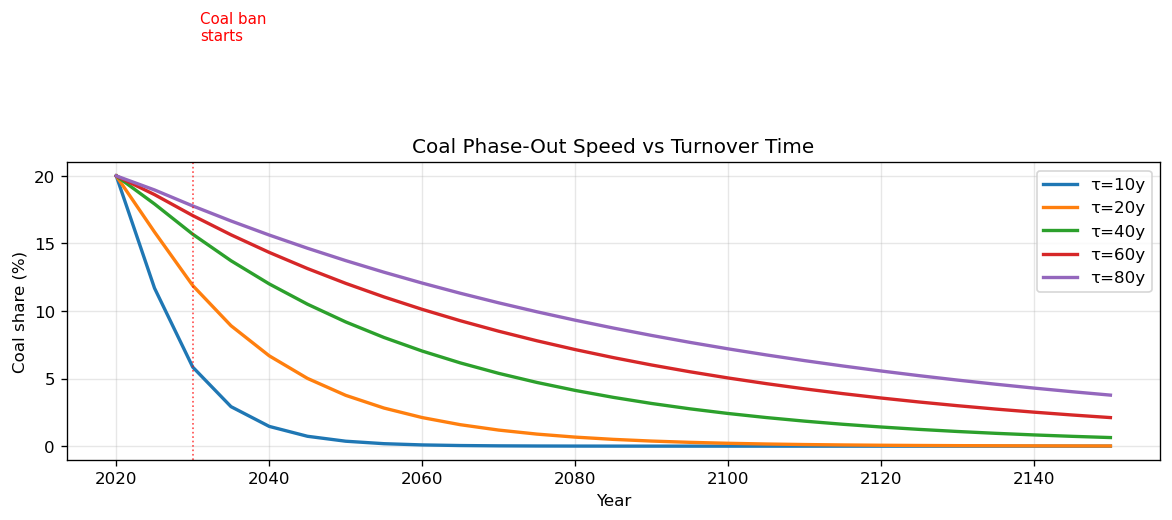

In [9]:
# Sensitivity: vary turnover time, track coal share with coal ban
taus_to_test = [10, 20, 40, 60, 80]
coal_traces = {}

for tau in taus_to_test:
    sec = ElectricitySector(turnover_time=float(tau))
    sec.calibrate(base_shares, fuel_prices)
    coal_share = []
    demand = base_total
    for yr in years:
        alpha = None
        if yr >= 2030:
            alpha = np.array([0.0 if t.name == 'coal' else 1.0 for t in sec.techs])
        gen = sec.compute_supply(fuel_prices, demand, year=yr, alpha=alpha)
        total = sum(gen.values())
        coal_share.append(gen['coal'] / total * 100 if total > 0 else 0)
        demand *= demand_growth ** TIMESTEP
    coal_traces[tau] = coal_share

plt.figure(figsize=(10, 5))
for tau in taus_to_test:
    plt.plot(years, coal_traces[tau], label=f'τ={tau}y', lw=2)

plt.axvline(2030, color='red', ls=':', lw=1, alpha=0.7)
plt.text(2031, 30, 'Coal ban\nstarts', fontsize=9, color='red')
plt.xlabel('Year')
plt.ylabel('Coal share (%)')
plt.title('Coal Phase-Out Speed vs Turnover Time')
plt.legend()
plt.tight_layout()
plt.show()

## 2.8 Full Model Run — Electricity Shares with Trade

In [10]:
# Read from the full model output files
import csv, os

output_csv = os.path.join('..', 'ghim_output', 'model_results.csv')
if os.path.exists(output_csv):
    with open(output_csv) as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    print(f'Loaded {len(rows)} rows from {output_csv}')
    print(f'Columns: {list(rows[0].keys())[:15]}...')
    csv_loaded = True
else:
    # Run model if output doesn't exist
    import subprocess
    result = subprocess.run(
        ['python', '-m', 'ghim.run', '--scenario', 'SSP2', '--no-trade'],
        capture_output=True, text=True, cwd='..'
    )
    if result.returncode != 0:
        print('Model run failed:')
        print(result.stderr[-2000:])
        csv_loaded = False
    else:
        with open(output_csv) as f:
            reader = csv.DictReader(f)
            rows = list(reader)
        print(f'Model run complete. Loaded {len(rows)} rows.')
        csv_loaded = True

Loaded 310 rows from ../ghim_output/model_results.csv
Columns: ['year', 'region', 'gdp_billion_usd', 'gross_output_billion_usd', 'net_output_billion_usd', 'ssp_reference_gdp_billion_usd', 'capital_stock_billion_usd', 'investment_billion_usd', 'energy_cost_billion_usd', 'tfp', 'population_million', 'total_energy_ej', 'electricity_price_usd_gj', 'refined_liquids_ej', 'emissions_mtco2']...


Electricity columns: ['elec_coal_ej', 'elec_gas_cc_ej', 'elec_nuclear_ej', 'elec_hydro_ej', 'elec_wind_ej', 'elec_solar_ej', 'elec_biomass_ej', 'elec_oil_ej']
Regions: ['Africa', 'Asia-Pacific Developed', 'Eastern Asia', 'Eurasia', 'Europe', 'Latin America and Caribbean', 'Middle East', 'North America', 'South-East Asia and developing Pacific', 'Southern Asia']


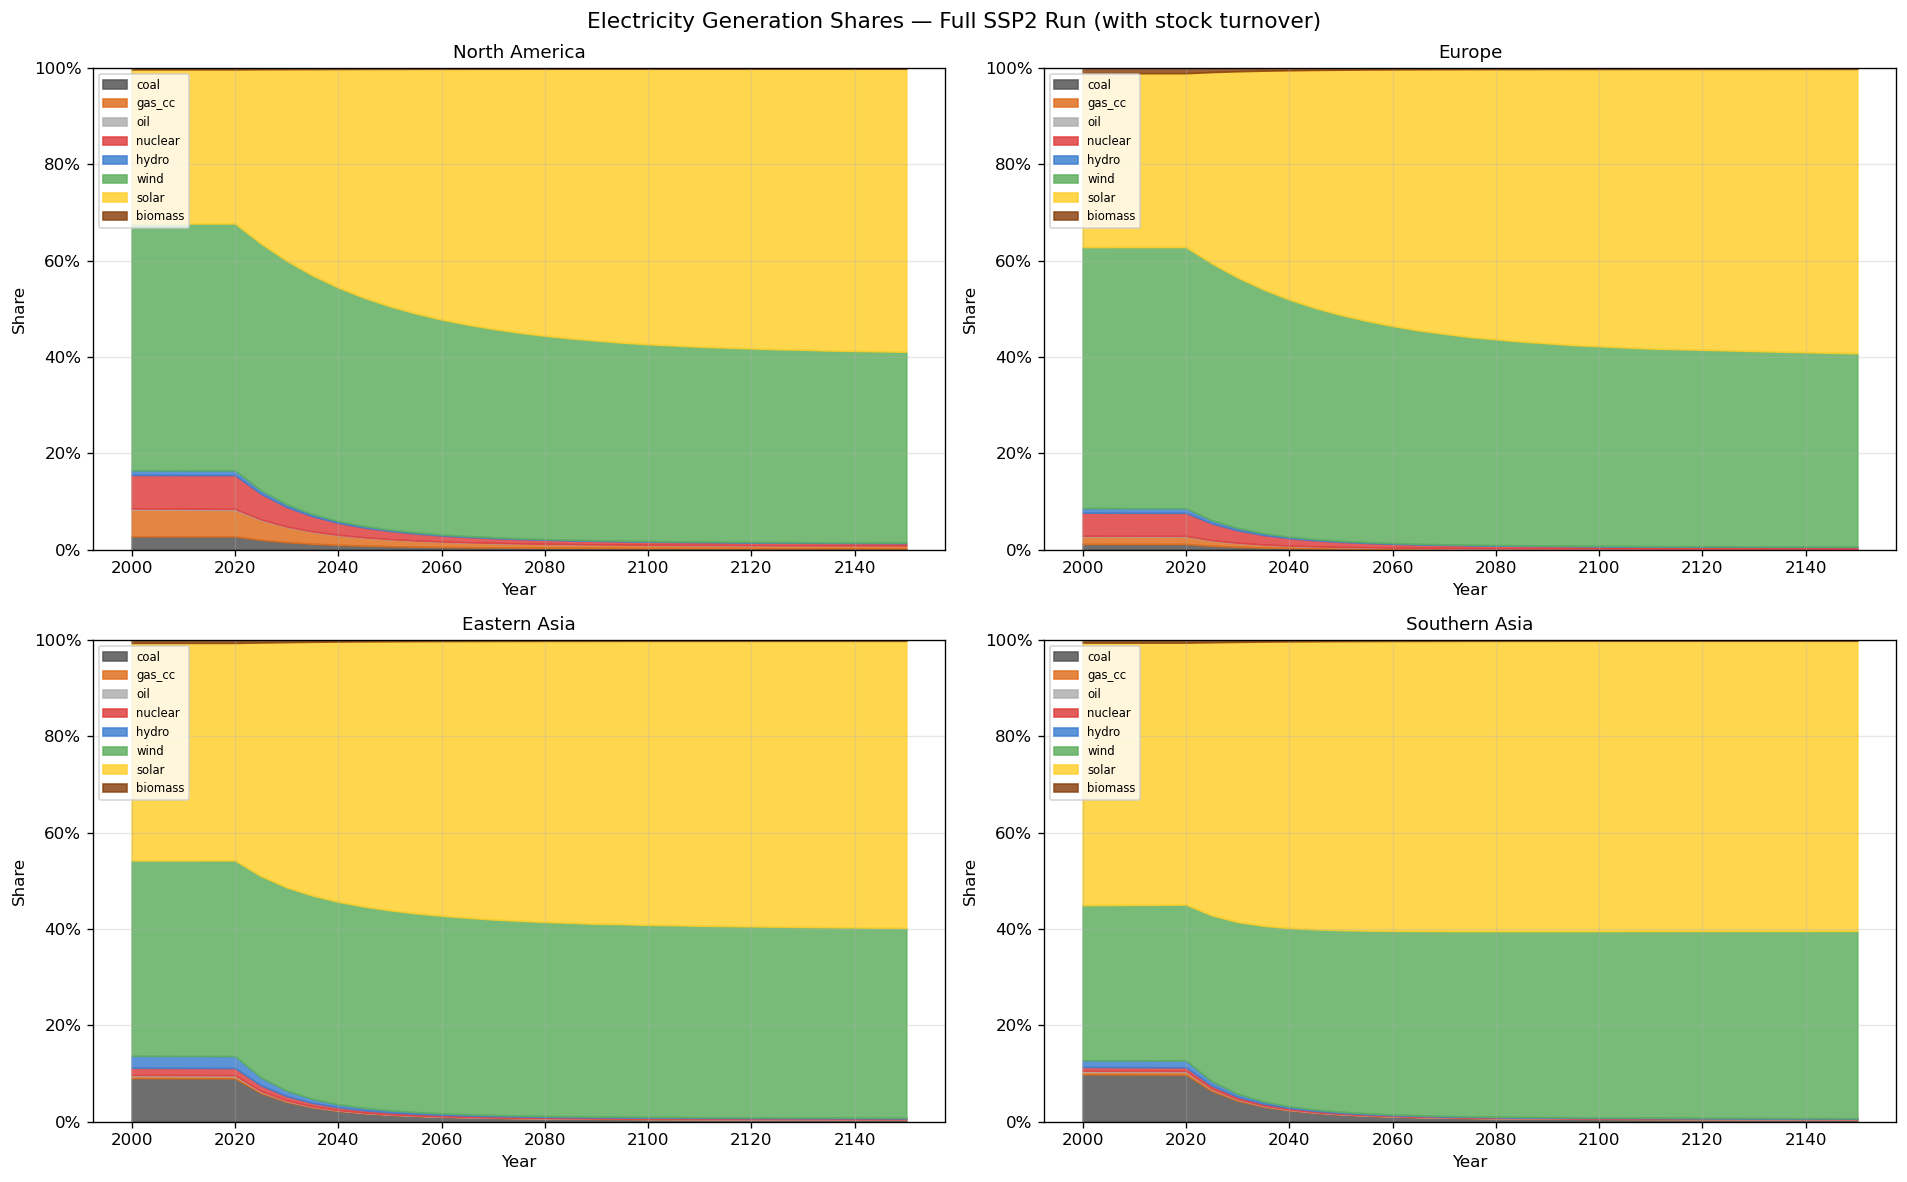

In [11]:
# Plot electricity shares by region from full model output
if csv_loaded and rows:
    regions = sorted(set(r['region'] for r in rows))
    elec_cols = [c for c in rows[0].keys() if c.startswith('elec_')]
    print(f'Electricity columns: {elec_cols}')
    print(f'Regions: {regions}')
    
    plot_regions = [r for r in ['North America', 'Europe', 'Eastern Asia', 'Southern Asia'] if r in regions]
    if not plot_regions:
        plot_regions = regions[:4]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    tech_order = ['coal', 'gas_cc', 'oil', 'nuclear', 'hydro', 'wind', 'solar', 'biomass']
    
    for ax, reg in zip(axes.flat, plot_regions):
        reg_rows = [r for r in rows if r['region'] == reg]
        reg_years = [int(r['year']) for r in reg_rows]
        
        bottom = np.zeros(len(reg_rows))
        for tech in tech_order:
            col = f'elec_{tech}_ej'
            if col not in reg_rows[0]:
                col = f'elec_{tech}'
            if col in reg_rows[0]:
                vals = np.array([float(r.get(col, 0)) for r in reg_rows])
                totals = np.array([
                    sum(float(r.get(f'elec_{t}_ej', r.get(f'elec_{t}', 0))) for t in tech_order)
                    for r in reg_rows
                ])
                shares = np.where(totals > 0, vals / totals, 0)
                ax.fill_between(reg_years, bottom, bottom + shares,
                               label=tech, color=colors.get(tech, '#999'), alpha=0.85)
                bottom += shares
        
        ax.set_title(reg, fontsize=11)
        ax.set_xlabel('Year')
        ax.set_ylabel('Share')
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.legend(loc='upper left', fontsize=7)
    
    fig.suptitle('Electricity Generation Shares — Full SSP2 Run (with stock turnover)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Skipping full model plots (no data available)')

## 2.9 Summary

### Key observations:

1. **Stock turnover creates realistic inertia** — coal can't disappear overnight even with a ban (τ=40y → ~85 years to 90% phase-out)
2. **Nested turnover** in demand trees means fuel switching operates at two speeds: structural composition (very slow) and fuel choice (moderate)
3. **Learning-by-doing** reinforces turnover dynamics: as solar/wind grow through turnover, their costs drop, making future target shares even larger
4. **Preference decay** gradually erodes incumbent advantages, allowing cost competition to dominate long-term

### Design trade-offs vs GCAM:

| Feature | GHIM | GCAM |
|---------|------|------|
| Vintage tracking | No (continuous blend) | Yes (multi-period cohorts) |
| Retirement | Implicit (τ blend rate) | Explicit (shutdown curve) |
| Computational cost | Low (1 array per sector) | Higher (vintage dimension) |
| Early retirement policy | Via α=0 + turnover | Explicit shutdown decision |
| Stranded assets | Not modeled | Partially modeled |